### Training script BERT 

Why BERT? 
LLMs are overkill for this problem. 
BERT is more efficient. 
Based on huggingface tutorial. 

### Import necessary packages & load data 

In [1]:
from datasets import load_from_disk
import datasets 
from transformers import AutoTokenizer 
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
from data.CyberMetric import CyberMetric_evaluator
from openai import OpenAI 
import re
import evaluate
import numpy as np
import torch 
#!pip install nlpaug
from transformers import Trainer 
from torch import nn 
num_classes = 9

KAs = {"0": "miscellaneous (this includes Computer Science, Business and Law, Communication and Networking, Information Technology, Cyberspace Practice, Pedagogy, and Intelligence)",
           "1": "data security", 
           "2": "software security",
           "3": "component security", 
           "4": "connection security", 
           "5": "system security", 
           "6": "human security", 
           "7": "organizational security",
           "8": "societal security"}

/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/RL/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
def clean_text(text): 
    special_chars = r'[\"\[\]\',]'
    cleaned_text = re.sub(special_chars, '', text)
    # replace - or _ with space 
    special_chars = r'[\_\-]'
    cleaned_text2 = re.sub(special_chars,' ', cleaned_text)
    return cleaned_text2 

clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])

def sigmoid(x):
   return 1/(1 + np.exp(-x))

def compute_metrics(eval_pred):
   predictions, labels = eval_pred
   predictions = sigmoid(predictions)
   predictions = (predictions > 0.5).astype(int).reshape(-1)
   return clf_metrics.compute(predictions=predictions, references=labels.astype(int).reshape(-1))

def preprocess_function(example, tokenizer):
    text = f"{example['Statement Description']}"  # our text to be labeled is the description of the KD
    text = text[13:]                              # remove "Knowledge of" since it's the same for every KD
    text = clean_text(text)                       # remove special characters
    one_hot = list(example.values())[0:9]         # read one-hot encoding 
    example = tokenizer(text)                     # tokenize text 
    example['labels'] = torch.tensor(one_hot).float()
    return example 

# custom trainer with class weights, from: https://discuss.huggingface.co/t/how-can-i-use-class-weights-when-training/1067/6
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels = inputs.get("labels")
        # forward pass
        outputs = model(**inputs)
        logits = outputs.get('logits')
        # compute custom loss [0.28267562272600055, 0.23929471032745592, 0.055695493982647636, 0.022949902043101034, 0.052616848586621884, 0.1575706689056815, 0.04114189756507137, 0.12930310663308145, 0.018751749230338653]
        # [0.3248811410459588, 0.08399366085578447, 0.04120443740095087, 0.025356576862123614, 0.12678288431061807, 0.08240887480190175, 0.00792393026941363, 0.27892234548335976, 0.028526148969889066]
        loss_fct = nn.CrossEntropyLoss(weight=torch.tensor(self.normalized_weights).cuda())
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels)      
        return (loss, outputs) if return_outputs else loss

    def compute_weights(self, dataset): 
        non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
        counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
        counts = np.bincount(non_oh)
        
        # compute class weights = n_samples / (n_classes * n_samplesj)
        weights = [1/x for x in counts]
        self.normalized_weights = [ 9*x / sum(weights) for x in weights]

In [3]:
from datasets import load_from_disk
import datasets 
from transformers import AutoTokenizer 
ds = load_from_disk("data/train.hf")
# convert to csv (necessary for k-fold cross validation
ds.to_csv("data/train_data.csv")

Creating CSV from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

63775

In [4]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from sklearn.model_selection import StratifiedKFold, KFold
from transformers import set_seed 
import copy
set_seed(42)

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')  
# to create a batch of examples. This dynamically pads the text to the lenght of the longest element in the batch. 
def preprocess(example):
        # preprocess and tokenize data 
        text = f"{example['Statement Description']}"       # our text to be labeled is the description of the KD
        text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
        text = clean_text(text)                            # remove special characters
        one_hot = list(example.values())[0:9]              # read one-hot encoding 
        example = tokenizer(text)                          # tokenize text 
        example['labels'] = torch.tensor(one_hot).float()
        return example 
    


[205  53  26  16  80  52   5 176  18]


Text(0.5, 1.0, 'label distribution 2017 KDs')

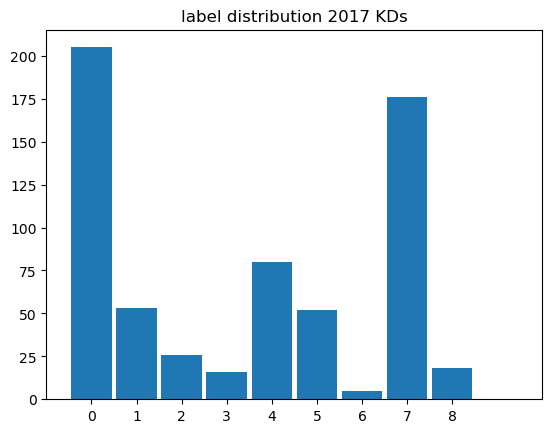

In [11]:
import matplotlib.pyplot as plt 
from collections import Counter 
dataset = copy.deepcopy(trans.data)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in dataset['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

# plot histogram of labels 
fig, ax = plt.subplots();
ax.bar(range(9), counts, width=0.9, align='center');
ax.set(xticks=range(9), xlim=[-1,10]);
ax.set_title('label distribution 2017 KDs')

In [12]:
print(dataset)

#import pandas as pd
# turn KDs into right format
#df_KDs = {'Statement Description': KDs}
#df_KDs = pd.DataFrame(df_KDs)
#print(df_KDs)

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 576
})


In [7]:
# oversampling 
#!pip install pytorch-multilabel-balanced-sampler
from pytorch_multilabel_balanced_sampler.samplers import RandomClassSampler, ClassCycleSampler, LeastSampledClassSampler 

def balance_dataset(dataset): 
    n_samples = 9*205
    sampler = LeastSampledClassSampler(labels=torch.tensor(dataset['labels']).to(torch.long))
    labels = []
    samples = []
    for sample in sampler: 
        labels.append(dataset['labels'][sample])
        samples.append(sample)
    
    balanced_ds = dataset.select(samples)
    return balanced_ds
    
dataset = copy.deepcopy(trans.data)
balanced_ds = balance_dataset(dataset)
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in balanced_ds['labels']], axis=0)
counts, bins = np.histogram(non_oh, bins=[0,1,2,3,4,5,6,7,8,9])
counts = np.bincount(non_oh)
print(counts)

# plot histogram of labels 
#fig, ax = plt.subplots();
#ax.bar(range(9), counts, width=0.9, align='center');
#ax.set(xticks=range(9), xlim=[-1,10]);
#ax.set_title('label distribution 2017 KDs')

In [8]:
# Data augmentation module 
import nlpaug.augmenter.word as naw 
import random 

def data_augmentation(example, rs=True, ri=True, swap=True, de=True): 
    #text = example['Statement Description']
    text = f"{example['Statement Description']}"       # our text to be labeled is the description of the KD
    text = text[13:]                                   # remove "Knowledge of" since it's the same for every KD
    text = clean_text(text) 
    before = text 
    augmentations = [] 
    augmentations.append('none')
    if ri == True: 
        augmentations.append('insertion')
    if rs == True: 
        augmentations.append('substitution')
    if swap == True: 
        augmentations.append('swap')
    if de == True: 
        augmentations.append('delete') 
    selected_augmentations = random.choices(augmentations, weights=[0.6, 0.1, 0.1, 0.1, 0.1]) 
    # insert some words in the sentence 
    if 'insertion' in selected_augmentations: 
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="insert")
        text = aug.augment(text)
    # replace word with a synonym 
    if 'substitution' in selected_augmentations: 
        aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute")
        text = aug.augment(text)
    # swap word randomly
    if 'swap' in selected_augmentations: 
        aug = naw.RandomWordAug(action="swap") 
        text = aug.augment(text)
    # delete word randomly 
    if 'delete' in selected_augmentations: 
        aug = naw.RandomWordAug()
        text = aug.augment(text)
    if 'none' not in selected_augmentations: 
        #print('before: ',before)
        #print('augmentation: ', text[0])
        example['Statement Description'] = clean_text(text[0])
        example = tokenizer(text[0]) 
        #print(example)
    return example

text = 'The quick brown fox jumps over the lazy dog' 
print(text)
#print(data_augmentation(text))

The quick brown fox jumps over the lazy dog


In [9]:
import datasets 
import pandas as pd
from datasets import Dataset 
from datasets import concatenate_datasets 
datasets.disable_caching()
class Transformer:
    def __init__(self, datapath, class_weights=False, model_name='distilbert-base-uncased',num_classes=9, k_folds=5, device=None): 
        self.num_classes = num_classes
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu") 
        self.model_name = model_name 
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)             # the tokenizer is the same for all folds 
        self.data_collator = DataCollatorWithPadding(tokenizer=self.tokenizer) # the data collator is the same for all folds 
        self.load_data(datapath)                                               # we can load and tokenize the data already 
        self.k_folds = KFold(n_splits=k_folds, shuffle=True, random_state=42)  # Stratified k-folds is not for multi-label problems
        self.class_weights = class_weights                                     # whether we weight the loss with class weights or not 
        
    def init_models(self, model_name): 
        # dropout = 02 (attention dropuot?) 
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=self.num_classes, dropout=0.2)

    def load_data(self, datapath): 
        dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
        dataset = dataset.remove_columns('KSAT ID')
        self.data = dataset.map(preprocess)

    def train(self, training_args, data_aug=False, balance=False, synthetic=False): 
        fold_results = [] 
        for fold, (train_idx, val_idx) in enumerate(self.k_folds.split(self.data)): 
            print(f"Training on fold {fold + 1}")
            train_dataset = copy.deepcopy(self.data.select(train_idx.tolist()))
            val_dataset = copy.deepcopy(self.data.select(val_idx.tolist()))
            self.init_models(self.model_name)                    # we must re-initiate the classification model for every fold
            # this is where we would add the synthetic data 
            #print(train_dataset['input_ids'][:5])
            #print(train_dataset['Statement Description'][:5])
            if data_aug == True: 
                #print('true')
                output = train_dataset.map(data_augmentation)
                train_dataset = copy.deepcopy(output)
                print(train_dataset['input_ids'][:5])
                print(train_dataset['Statement Description'][:5])

            if synthetic == True: 
                # load synthetic dataset 
                input1 = pd.read_csv("data/train_synthetic_v2.csv")
                input2 = pd.read_csv("data/train_synthetic_v2_labels.csv")
                input1 = input2.merge(input1, on="Unnamed: 0", how='right')
                dataset2 = Dataset.from_pandas(input1)
                dataset2 = dataset2.remove_columns(['Unnamed: 0','label'])
                dataset2 = dataset2.map(preprocess)
                print(dataset2)
                #print(dataset2)
                # merge train_dataset with synthetic dataset. 
                train_dataset = concatenate_datasets([train_dataset, dataset2])
                print(train_dataset)
            print(val_dataset)
            if balance == True: 
                train_dataset = balance_dataset(copy.deepcopy(train_dataset))
            
            if self.class_weights == True: 
                self.trainer = CustomTrainer(
                model=self.model,
                args=training_args,
                train_dataset=train_dataset,
                eval_dataset=val_dataset,
                tokenizer=self.tokenizer,
                data_collator=self.data_collator,
                compute_metrics=compute_metrics,
                    
            )
                self.trainer.compute_weights(train_dataset)
                print('weights: ',self.trainer.normalized_weights)

            else: 
                self.trainer = Trainer(
                model=self.model,
                args=training_args,
                train_dataset=train_dataset,
                eval_dataset=val_dataset,
                tokenizer=self.tokenizer,
                data_collator=self.data_collator,
                compute_metrics=compute_metrics,
            )
          
            self.trainer.train()
            metrics = self.trainer.evaluate()
            fold_results.append(metrics)
            print(f"Fold {fold+1} results: {metrics}")

        avg_metrics = {key: np.mean([fold[key] for fold in fold_results]) for key in fold_results[0]}
        print(f"Average metrics across all folds: {avg_metrics}")
        return avg_metrics

datapath = "data/train_data.csv"
trans = Transformer(datapath, k_folds=5, class_weights=False) 
#print(trans.data)
training_args = TrainingArguments(
        output_dir="DistilBERTv1",
        learning_rate=5e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=20,
        weight_decay=0.01,
        logging_steps=100,
        # I added these three 
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        save_total_limit=1,
    )
#print(trans.val_dataset)
trans.train(training_args, balance=False, data_aug=False, synthetic=True)


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/576 [00:00<?, ? examples/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Training on fold 1


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

/local/tmp.3439013/ipykernel_1366687/2598303194.py:75: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  self.trainer = Trainer(
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 6357
})
Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 6818
})
Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 115
})


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.372100,0.291393,0.874396,0.444444,0.456140,0.433333
2,0.314500,0.274958,0.889855,0.512821,0.526316,0.500000
3,0.276900,0.259495,0.894686,0.511211,0.553398,0.475000
4,0.257400,0.304123,0.889855,0.516949,0.525862,0.508333
5,0.226400,0.278034,0.900483,0.572614,0.570248,0.575000
6,0.206600,0.296498,0.895652,0.557377,0.548387,0.566667
7,0.186600,0.327930,0.891787,0.529412,0.533898,0.525000
8,0.178300,0.348561,0.890821,0.531120,0.528926,0.533333
9,0.164000,0.363392,0.891787,0.544715,0.531746,0.558333
10,0.160300,0.389886,0.891787,0.555556,0.530303,0.583333


Fold 5 results: {'eval_loss': 0.43920978903770447, 'eval_accuracy': 0.9014492753623189, 'eval_f1': 0.5785123966942148, 'eval_precision': 0.5737704918032787, 'eval_recall': 0.5833333333333334, 'eval_runtime': 0.4407, 'eval_samples_per_second': 260.922, 'eval_steps_per_second': 18.151, 'epoch': 20.0}
Average metrics across all folds: {'eval_loss': 0.46319437623023985, 'eval_accuracy': 0.8886823255039149, 'eval_f1': 0.5386680752076647, 'eval_precision': 0.5451381495529894, 'eval_recall': 0.5325209724605756, 'eval_runtime': 0.4427, 'eval_samples_per_second': 260.86440000000005, 'eval_steps_per_second': 18.115000000000002, 'epoch': 20.0}


{'eval_loss': 0.46319437623023985,
 'eval_accuracy': 0.8886823255039149,
 'eval_f1': 0.5386680752076647,
 'eval_precision': 0.5451381495529894,
 'eval_recall': 0.5325209724605756,
 'eval_runtime': 0.4427,
 'eval_samples_per_second': 260.86440000000005,
 'eval_steps_per_second': 18.115000000000002,
 'epoch': 20.0}

In [7]:
# load 2017 KDs
dataset = datasets.load_dataset("csv",data_files={"train": "data/train_data.csv"}, split='train')
dataset = dataset.remove_columns('KSAT ID')
print(dataset)
train_val_split = dataset.train_test_split(test_size=0.1, seed=42) 
train_dataset = train_val_split['train']
val_dataset = train_val_split['test']

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description'],
    num_rows: 576
})


In [52]:
# load synthetic dataset 
import pandas as pd
from datasets import Dataset 
input1 = pd.read_csv("data/train_synthetic_v1.csv")
input2 = pd.read_csv("data/train_synthetic_v1_labels.csv")
input1 = input2.merge(input1, on="Unnamed: 0", how='right')
dataset2 = Dataset.from_pandas(input1)
dataset2 = dataset2.remove_columns(['Unnamed: 0','label'])
print(dataset2)
# merge train_dataset with synthetic dataset. 
from datasets import concatenate_datasets 
train_dataset = concatenate_datasets([train_dataset, dataset2])
print(train_dataset)

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description'],
    num_rows: 1548
})


Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description'],
    num_rows: 2066
})


### Define functions (import these in a later stage). 

### Tokenize dataset 

In [55]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [56]:
tokenized_train = train_dataset.map(preprocess_function) 
tokenized_val = val_dataset.map(preprocess_function)
print(tokenized_train)

Map:   0%|          | 0/2066 [00:00<?, ? examples/s]

Map:   0%|          | 0/58 [00:00<?, ? examples/s]

Dataset({
    features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', 'Statement Description', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 2066
})


### Fine-tune with Trainer 

In [75]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
# to create a batch of examples. This dynamically pads the text to the lenght of the longest element in the batch. 
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=num_classes)
#from torchinfo import summary 
#summary(model)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [80]:
training_args = TrainingArguments(
    output_dir="DistilBERTv2",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=16,
    num_train_epochs=25,
    weight_decay=0.01,
    logging_steps=100,
    # I added these three 
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    save_total_limit=1,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    # I added this to compute metrics. 
    compute_metrics=compute_metrics,
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/local/tmp.3422166/ipykernel_2239932/910210077.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  trainer = CustomTrainer(
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [81]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.062800,2.398516,0.829502,0.485549,0.371681,0.700000
2,0.874200,2.134770,0.837165,0.519774,0.393162,0.766667
3,0.884000,3.092497,0.850575,0.486842,0.402174,0.616667
4,0.884300,2.712057,0.862069,0.538462,0.437500,0.700000
5,0.751100,2.608346,0.879310,0.553191,0.481481,0.650000
6,0.777100,3.074444,0.844828,0.477419,0.389474,0.616667
7,0.967900,2.444560,0.871648,0.524823,0.456790,0.616667
8,0.803800,2.747569,0.865900,0.507042,0.439024,0.600000
9,0.844900,2.636265,0.862069,0.506849,0.430233,0.616667
10,1.007100,2.685127,0.871648,0.503704,0.453333,0.566667


TrainOutput(global_step=12925, training_loss=0.762486086389774, metrics={'train_runtime': 549.3388, 'train_samples_per_second': 94.022, 'train_steps_per_second': 23.528, 'total_flos': 171599299593876.0, 'train_loss': 0.762486086389774, 'epoch': 25.0})

### Evaluation

In [84]:
import os
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import AutoConfig
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
print(os.path.exists("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130/config.json"))
path = "/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv2/checkpoint-1034/"
print(os.path.isfile("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130/config.json"))
#config = AutoConfig.from_pretrained("local:/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130")
#"./DistilBERTv1/checkpoint-130/config.json"
model = AutoModelForSequenceClassification.from_pretrained(path
                                                           , num_labels=num_classes)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    # I added this to compute metrics. 
    compute_metrics=compute_metrics,
)

# load the best weights and inspect. 
# plot confusion matrices! 
from sklearn.metrics import multilabel_confusion_matrix
import os 
from transformers.trainer_callback import TrainerState 

labels = np.zeros((len(dataset),num_classes))
preds = np.zeros((len(dataset),num_classes))
output = trainer.predict(tokenized_val)
#print(output)
predictions = sigmoid(output[0])
predictions = (predictions > 0.5).astype(int) #.reshape(-1)

print(multilabel_confusion_matrix(output[1].astype(int), predictions))
# [ TN FP ]
# [ FN TP ] 
# maybe plot this as column plots? 

/local/tmp.3422166/ipykernel_2239932/1519345436.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


False
False


[[[30 13]
  [ 2 13]]

 [[41 15]
  [ 1  1]]

 [[52  3]
  [ 1  2]]

 [[55  0]
  [ 1  2]]

 [[40  7]
  [ 2  9]]

 [[43 11]
  [ 2  2]]

 [[56  2]
  [ 0  0]]

 [[24 15]
  [ 2 17]]

 [[50  5]
  [ 3  0]]]


In [55]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import AutoConfig
import sys
sys.path.append("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu")
print(os.path.exists("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130/config.json"))
path = "/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130/"
print(os.path.isfile("/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130/config.json"))
#config = AutoConfig.from_pretrained("local:/mimer/NOBACKUP/groups/naiss2024-22-903/LLMedu/DistilBERTv1/checkpoint-130")
#"./DistilBERTv1/checkpoint-130/config.json"
model = AutoModelForSequenceClassification.from_pretrained(path
                                                           , num_labels=num_classes)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    # I added this to compute metrics. 
    compute_metrics=compute_metrics,
)

# load the best weights and inspect. 
# plot confusion matrices! 
from sklearn.metrics import multilabel_confusion_matrix
import os 
from transformers.trainer_callback import TrainerState 

labels = np.zeros((len(dataset),num_classes))
preds = np.zeros((len(dataset),num_classes))
output = trainer.predict(tokenized_val)
#print(output)
predictions = sigmoid(output[0])
predictions = (predictions > 0.5).astype(int) #.reshape(-1)

print(multilabel_confusion_matrix(output[1].astype(int), predictions))
# [ TN FP ]
# [ FN TP ] 
# maybe plot this as column plots? 

/local/tmp.3405036/ipykernel_1667434/1019722757.py:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


True
True


[[[43  0]
  [ 2 13]]

 [[56  0]
  [ 0  2]]

 [[57  0]
  [ 1  0]]

 [[57  0]
  [ 1  0]]

 [[49  0]
  [ 2  7]]

 [[51  0]
  [ 7  0]]

 [[58  0]
  [ 0  0]]

 [[32  2]
  [ 1 23]]

 [[57  0]
  [ 1  0]]]


In [54]:
# load the best weights and inspect. 
# plot confusion matrices! 
from sklearn.metrics import multilabel_confusion_matrix
import os 
from transformers.trainer_callback import TrainerState 

labels = np.zeros((len(dataset),num_classes))
preds = np.zeros((len(dataset),num_classes))
output = trainer.predict(tokenized_val)
#print(output)
predictions = sigmoid(output[0])
predictions = (predictions > 0.5).astype(int) #.reshape(-1)

print(multilabel_confusion_matrix(output[1].astype(int), predictions))
# [ TN FP ]
# [ FN TP ] 
# maybe plot this as column plots? 

[[[43  0]
  [ 2 13]]

 [[56  0]
  [ 0  2]]

 [[57  0]
  [ 1  0]]

 [[57  0]
  [ 1  0]]

 [[49  0]
  [ 2  7]]

 [[51  0]
  [ 7  0]]

 [[58  0]
  [ 0  0]]

 [[32  2]
  [ 1 23]]

 [[57  0]
  [ 1  0]]]


In [28]:
# load the best weights and inspect. 
# plot confusion matrices! 
from sklearn.metrics import multilabel_confusion_matrix
import os 
from transformers.trainer_callback import TrainerState 
save_dir = "DistilBERTv2"
ckpt_dirs = os.listdir(save_dir)
print(ckpt_dirs)
#ckpt_dirs = sorted(ckpt_dirs, key=lambda x: int(x.split('-')[1]))
last_ckpt = ckpt_dirs[0]
print(last_ckpt)
state = TrainerState.load_from_json(f"{save_dir}/{last_ckpt}/trainer_state.json")
print(state.best_model_checkpoint)

#non_oh = [list(np.where(row==1)[0]) for row in labels]
#non_oh2 = [list(np.where(row==1)[0]) for row in preds]
labels = np.zeros((len(dataset),num_classes))
preds = np.zeros((len(dataset),num_classes))
output = trainer.predict(tokenized_val)
#print(output)
predictions = sigmoid(output[0])
predictions = (predictions > 0.5).astype(int) #.reshape(-1)

print(multilabel_confusion_matrix(output[1].astype(int), predictions))
# [ TN FP ]
# [ FN TP ] 
# maybe plot this as column plots? 

['checkpoint-4136', 'runs']
checkpoint-4136
DistilBERTv2/checkpoint-4136


[[[40  3]
  [ 3 12]]

 [[55  1]
  [ 0  2]]

 [[57  0]
  [ 1  0]]

 [[57  0]
  [ 1  0]]

 [[48  1]
  [ 7  2]]

 [[51  0]
  [ 4  3]]

 [[58  0]
  [ 0  0]]

 [[30  4]
  [ 7 17]]

 [[57  0]
  [ 1  0]]]


In [25]:
# load the best weights and inspect. 
import os 
from transformers.trainer_callback import TrainerState 
save_dir = "DistilBERTv1"
ckpt_dirs = os.listdir(save_dir)
print(ckpt_dirs)
#ckpt_dirs = sorted(ckpt_dirs, key=lambda x: int(x.split('-')[1]))
last_ckpt = ckpt_dirs[-1]
print(last_ckpt)
state = TrainerState.load_from_json(f"{save_dir}/{last_ckpt}/trainer_state.json")
print(state.best_model_checkpoint)

['runs', 'checkpoint-130']
checkpoint-130
DistilBERTv1/checkpoint-130


In [29]:
# plot confusion matrices! 
from sklearn.metrics import multilabel_confusion_matrix
#non_oh = [list(np.where(row==1)[0]) for row in labels]
#non_oh2 = [list(np.where(row==1)[0]) for row in preds]
labels = np.zeros((len(dataset),num_classes))
preds = np.zeros((len(dataset),num_classes))
output = trainer.predict(tokenized_val,load_from_checkpoint=True,save_dir = "DistilBERTv1")
#print(output)
predictions = sigmoid(output[0])
predictions = (predictions > 0.5).astype(int) #.reshape(-1)

print(multilabel_confusion_matrix(output[1].astype(int), predictions))
# [ TN FP ]
# [ FN TP ] 
# maybe plot this as column plots? 

TypeError: predict() got an unexpected keyword argument 'load_from_checkpoint'

In [56]:
print(tokenized_train['labels'][0])
c = tokenized_train['labels'][0]
print(c[0])
print(np.where(np.array(c)==1.))

[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0
(array([0, 2]),)


(array([185.,  47.,  22.,  14.,   0.,  71.,  47.,   5., 162.,  16.]),
 array([0. , 0.8, 1.6, 2.4, 3.2, 4. , 4.8, 5.6, 6.4, 7.2, 8. ]),
 <BarContainer object of 10 artists>)

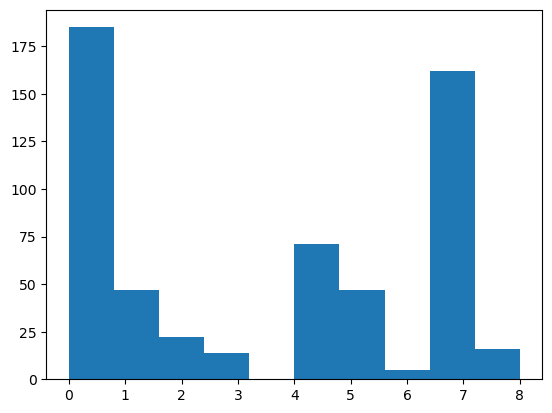

In [58]:
import matplotlib.pyplot as plt 
from collections import Counter 
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in tokenized_train['labels']], axis=0)
counts, bins = np.histogram(non_oh)
plt.hist(bins[:-1], bins, weights=counts)

(array([20.,  6.,  4.,  2.,  0.,  9.,  5.,  0., 14.,  2.]),
 array([0. , 0.8, 1.6, 2.4, 3.2, 4. , 4.8, 5.6, 6.4, 7.2, 8. ]),
 <BarContainer object of 10 artists>)

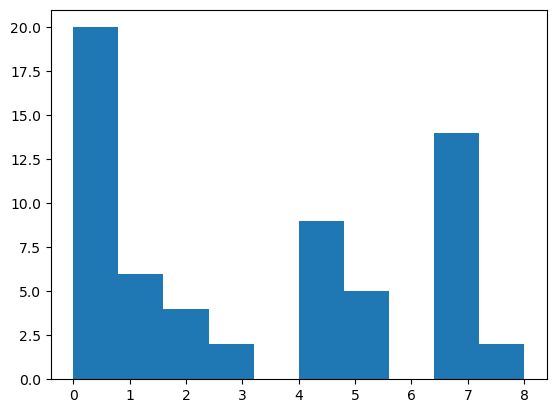

In [59]:
non_oh = np.concatenate([list(np.where(np.array(row)==1.)[0]) for row in tokenized_val['labels']], axis=0)
counts, bins = np.histogram(non_oh)
plt.hist(bins[:-1], bins, weights=counts)